# GS55 — Step 0: Assign CODA organ labels to StarDist GeoJSONs

Reads each StarDist polygon GeoJSON (20x coordinates) and the matching
whole-slide CODA classification mask (5x), then writes a new GeoJSON where
every nucleus has a `classification.name` property.

**No bounding-box files are needed** — the GS55 CODA masks cover the full
slide, so a single scale factor maps 20x → 5x coordinates.

| Cell | Purpose |
|------|---------|
| 1 | Imports |
| **2** | **Parameters ← edit here** |
| 3 | Process all slides |
| 4 | Sanity-check overlay plot |

---
## 1 · Imports

In [1]:
import sys
from pathlib import Path
from tqdm import tqdm
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json

# dataset_utils is in the same folder as this notebook
sys.path.insert(0, str(Path.cwd()))
from dataset_utils import assign_coda_to_geojson, polygon_centroid

print("Imports OK")

Imports OK


---
## 2 · Parameters  ← edit here

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
# StarDist nuclear polygons at 20x (input)
GEOJSON_DIR = Path(r"\\kittyserverdw\Andre_kit\data\monkey_fetus\bissected_monkey_GS55\StarDist_10_10_2025_cross_fetal_species\json\geojsons\32_polys_20x")

# CODA whole-slide classification masks at 5x (input)
MASK_DIR = Path(r"\\kittyserverdw\Andre_kit\data\monkey_fetus\bissected_monkey_GS55\5x\classification_MODEL1_5x_GS40_GS55_06_10_2025_45_big_tiles_inceptionresnetv2")

# Output: CODA-labelled GeoJSONs
OUT_DIR = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\geojson_CODAclass")

# ── Resolution ─────────────────────────────────────────────────────────────────
# GS55 scanned at 20x; CODA masks are at 5x (MPP_MASK = 2 µm/px)
MPP_20X  = 0.4416   # µm/px at 20x (GeoJSON coordinate space)
MPP_MASK = 2.0      # µm/px at 5x  (CODA mask pixel space)
# No bounding-box files needed — GS55 CODA masks cover the full slide.

# ── Class palette (must match training) ────────────────────────────────────────
LABELS = [
    "bone",   "brain",  "eye",       "heart",     "lungs",
    "GI",     "liver",  "spleen",    "pancreas",  "kidney",
    "mesokidney", "collagen", "ear", "nontissue", "thymus",
    "thyroid", "bladder", "skull",   "spleen2",
]
COLORS = [
    [214,212,161], [247,184, 67], [136,232, 95], [140, 13, 13], [ 38, 27,166],
    [ 13,125, 11], [179, 50,108], [228,235,131], [156, 96,235], [ 46,190,230],
    [150,255,245], [254,222,255], [235,154,108], [255,255,255], [  9, 64,116],
    [255,255, 74], [178,178,  0], [214,212,161], [ 54, 83, 89],
]

print(f"GeoJSON dir  : {GEOJSON_DIR}")
print(f"  exists     : {GEOJSON_DIR.exists()}")
print(f"Mask dir     : {MASK_DIR}")
print(f"  exists     : {MASK_DIR.exists()}")
print(f"Output dir   : {OUT_DIR}")

GeoJSON dir  : \\kittyserverdw\Andre_kit\data\monkey_fetus\bissected_monkey_GS55\StarDist_10_10_2025_cross_fetal_species\json\geojsons\32_polys_20x
  exists     : True
Mask dir     : \\kittyserverdw\Andre_kit\data\monkey_fetus\bissected_monkey_GS55\5x\classification_MODEL1_5x_GS40_GS55_06_10_2025_45_big_tiles_inceptionresnetv2
  exists     : True
Output dir   : \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\geojson_CODAclass


---
## 3 · Run: assign CODA labels to all slides

In [3]:
# ── Process all slides ─────────────────────────────────────────────────────────
OUT_DIR.mkdir(parents=True, exist_ok=True)

gj_files = sorted(GEOJSON_DIR.glob("*.geojson"))
print(f"Found {len(gj_files)} GeoJSON files")

skipped = []
for gj_path in tqdm(gj_files, desc="Assigning CODA labels"):
    out_path = OUT_DIR / gj_path.name
    if out_path.exists():
        continue  # already processed — delete file to redo

    # Try .tif first, fall back to .png
    mask_path = MASK_DIR / f"{gj_path.stem}.tif"
    if not mask_path.exists():
        mask_path = MASK_DIR / f"{gj_path.stem}.png"

    if not mask_path.exists():
        skipped.append(gj_path.stem)
        continue

    n = assign_coda_to_geojson(
        geojson_path=gj_path,
        mask_path=mask_path,
        out_path=out_path,
        labels=LABELS,
        colors=COLORS,
        mpp_20x=MPP_20X,
        mpp_mask=MPP_MASK,
    )

print(f"\nDone. Skipped {len(skipped)} slides (no matching mask):")
for s in skipped[:10]:
    print(f"  {s}")

Found 14 GeoJSON files


Assigning CODA labels: 100%|██████████| 14/14 [44:19<00:00, 189.99s/it] 


Done. Skipped 0 slides (no matching mask):


---
## Sanity check — single slide

Run the cell below to confirm centroids land correctly inside the CODA mask.
Pick a different `SAMPLE_IDX` if the default slide is not representative.

Slide      : monkey_fetus_GS55_0001
Mask shape : 17381 x 10881 px
Centroids  : 1,964,551 nuclei — 100.0% inside mask bounds


C:\Users\Andre\AppData\Local\Temp\ipykernel_67280\756341229.py:49: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Andre\anaconda3\envs\convnext_stardist_mt\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


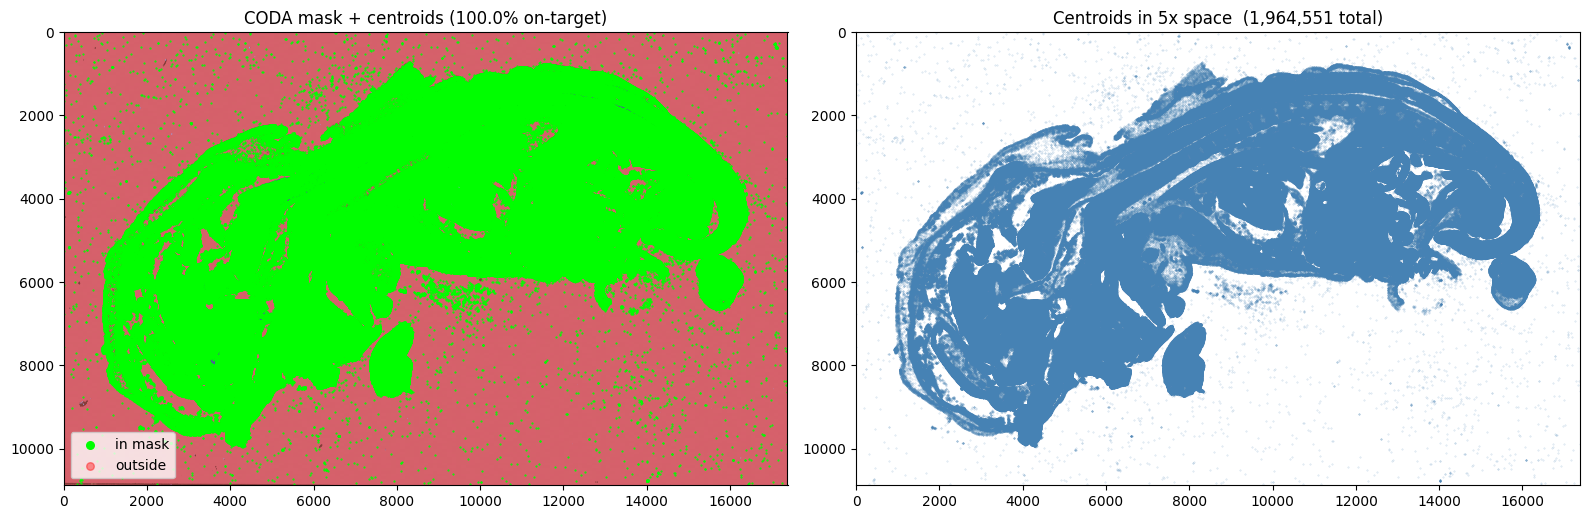

In [4]:
SAMPLE_IDX = 0   # ← change to check a different slide

gj_files = sorted(GEOJSON_DIR.glob("*.geojson"))
gj_path  = gj_files[SAMPLE_IDX]

mask_path = MASK_DIR / f"{gj_path.stem}.tif"
if not mask_path.exists():
    mask_path = MASK_DIR / f"{gj_path.stem}.png"

scale = MPP_20X / MPP_MASK   # 20x → 5x coordinate scale
mask  = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
data  = json.loads(gj_path.read_text(encoding="utf-8"))
feats = data if isinstance(data, list) else data.get("features", [])

cx_list, cy_list = [], []
for feat in feats:
    ring = feat.get("geometry", {}).get("coordinates", [[]])[0]
    cx, cy = polygon_centroid(ring)
    if cx is not None:
        cx_list.append(cx)
        cy_list.append(cy)

cx_20x, cy_20x = np.array(cx_list), np.array(cy_list)
cx_5x  = cx_20x * scale
cy_5x  = cy_20x * scale

in_mask = (
    (cx_5x >= 0) & (cx_5x < mask.shape[1]) &
    (cy_5x >= 0) & (cy_5x < mask.shape[0])
)
print(f"Slide      : {gj_path.stem}")
print(f"Mask shape : {mask.shape[1]} x {mask.shape[0]} px")
print(f"Centroids  : {len(cx_20x):,} nuclei — {in_mask.mean()*100:.1f}% inside mask bounds")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(mask, cmap="tab20b")
axes[0].scatter(cx_5x[in_mask],  cy_5x[in_mask],  s=0.3, color="lime",  label="in mask")
axes[0].scatter(cx_5x[~in_mask], cy_5x[~in_mask], s=0.3, color="red",   label="outside", alpha=0.4)
axes[0].set_title(f"CODA mask + centroids ({in_mask.mean()*100:.1f}% on-target)")
axes[0].legend(markerscale=10)

axes[1].scatter(cx_5x, cy_5x, s=0.1, alpha=0.3, color="steelblue")
axes[1].set_xlim(0, mask.shape[1])
axes[1].set_ylim(mask.shape[0], 0)
axes[1].set_title(f"Centroids in 5x space  ({len(cx_5x):,} total)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()